# Synthetic Model Generator

- define mesh & discretization
- define topography
- define earth vs air
- define density map

In [1]:
import numpy as np
from scipy.interpolate import LinearNDInterpolator
import matplotlib as mpl
import matplotlib.pyplot as plt
import os

from simpeg import maps
from simpeg.potential_fields import gravity
from simpeg.utils import model_builder
from discretize import TensorMesh
from discretize.utils import mkvc, active_from_xyz
from simpeg import (
    maps,
    data,
    data_misfit,
    inverse_problem,
    regularization,
    optimization,
    directives,
    inversion,
    utils,
)

from plots import plot_density_contrast, plot_gravity_measurements

### define & generate topography

In [2]:
def synthetic_topography(
    x_min=-200, x_max=200,
    y_min=-200, y_max=200,
    dx=10, dy=10,
    base_level=0.0,
    fbm_amp=20.0,
    seed=0,
    noise_sigma=0.5,
    scatter_fraction=0.0,
):
    """
    Return (N,3) array of x,y,z points representing synthetic topography.

    Parameters
    ----------
    x_min, x_max, y_min, y_max : float
        Domain bounds.
    dx, dy : float
        Sampling grid spacing.
    base_level : float
        Base elevation (meters).
    fbm_amp : float
        Relief amplitude (meters).
    seed : int
        RNG seed.
    noise_sigma : float
        Std deviation of Gaussian noise on z.
    scatter_fraction : float
        Fraction of points randomly dropped (0–1).

    Returns
    -------
    xyz : ndarray, shape (N,3)
        Point cloud of synthetic topography.
    """
    rng = np.random.default_rng(seed)

    xs = np.arange(x_min, x_max + 1e-9, dx)
    ys = np.arange(y_min, y_max + 1e-9, dy)
    X, Y = np.meshgrid(xs, ys, indexing="xy")

    # synthetic hills from sinusoids
    Z = base_level + fbm_amp * (
        np.sin(0.01*X + seed) * np.cos(0.01*Y + seed/2)
        + 0.5*np.sin(0.03*X) * np.cos(0.02*Y)
    )

    # add noise
    Z += rng.normal(0.0, noise_sigma, size=Z.shape)

    # flatten
    XX, YY, ZZ = mkvc(X), mkvc(Y), mkvc(Z)

    # optional subsample to simulate scattered points
    if scatter_fraction > 0:
        keep = rng.random(XX.size) > scatter_fraction
        XX, YY, ZZ = XX[keep], YY[keep], ZZ[keep]

    return np.c_[XX, YY, ZZ]

# Plot
topo_xyz = synthetic_topography()

### define tensor mesh (a SIMPEG util)

In [3]:
dh = 5.0
hx = [(dh, 5, -1.3), (dh, 40), (dh, 5, 1.3)]
hy = [(dh, 5, -1.3), (dh, 40), (dh, 5, 1.3)]
hz = [(dh, 5, -1.3), (dh, 15)]
mesh = TensorMesh([hx, hy, hz], "CCN")

### define cells

- earth vs air
- density map

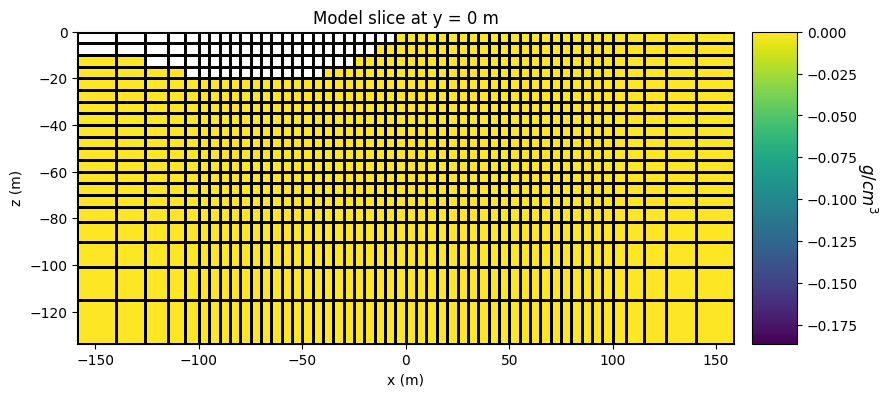

In [4]:

# Find the indices of the active cells in forward model (ones below surface)
ind_active = active_from_xyz(mesh, topo_xyz)

# Define mapping from model to active cells
nC = int(ind_active.sum())
model_map = maps.IdentityMap(nP=nC)  # model consists of a value for each active cell

# Define and plot starting model
starting_model = np.zeros(nC)

# Define density contrast values for each unit in g/cc
background_density = 0.0
block_density = -0.2

# Define model. Models in SimPEG are vector arrays.
true_model = background_density * np.ones(nC)

def add_random_blocks(
    mesh,
    ind_active,
    base_model=None,
    n_blocks=1,
    size_frac_range=(0.05, 0.30),     # each block spans 5–30% of domain per axis
    density_range=(-0.40, -0.10),     # g/cc; choose negatives for density deficit
    seed=4,
    max_tries=200,
    enforce_nonoverlap=True,
):
    """
    Returns (model, blocks_mask) where:
      - model is a copy of base_model (or zeros) with random blocks painted in
      - blocks_mask is a boolean mask (on active cells) of all block cells
    """
    rng = np.random.default_rng(seed)
    # Active cell centers (x, y, z)
    CCa = mesh.gridCC[ind_active]  # shape (n_active, 3)
    x, y, z = CCa[:, 0], CCa[:, 1], CCa[:, 2]
    x_min, x_max = float(x.min()), float(x.max())
    y_min, y_max = float(y.min()), float(y.max())
    z_min, z_max = float(z.min()), float(z.max())

    Lx, Ly, Lz = x_max - x_min, y_max - y_min, z_max - z_min
    # Start from provided base_model or zeros
    if base_model is None:
        model = np.zeros(ind_active.sum(), dtype=float)
    else:
        model = base_model.copy()

    # Track “occupied” cells if we want non-overlap
    occupied = np.zeros_like(model, dtype=bool)

    for k in range(n_blocks):
        placed = False
        for _ in range(max_tries):
            # Random physical sizes (axis-aligned prisms)
            fx = rng.uniform(*size_frac_range)
            fy = rng.uniform(*size_frac_range)
            fz = rng.uniform(*size_frac_range)
            sx, sy, sz = fx * Lx, fy * Ly, fz * Lz

            # Guard tiny or degenerate sizes
            if sx <= 0 or sy <= 0 or sz <= 0:
                continue

            # Random centers (keep the full block inside domain extents)
            cx = rng.uniform(x_min + sx / 2, x_max - sx / 2)
            cy = rng.uniform(y_min + sy / 2, y_max - sy / 2)
            cz = rng.uniform(z_min + sz / 2, z_max - sz / 2)

            # Axis-aligned bounds
            x0, x1 = cx - sx / 2, cx + sx / 2
            y0, y1 = cy - sy / 2, cy + sy / 2
            z0, z1 = cz - sz / 2, cz + sz / 2

            # Boolean mask on *active* cells only
            mask_k = (
                (x >= x0) & (x <= x1) &
                (y >= y0) & (y <= y1) &
                (z >= z0) & (z <= z1)
            )

            # Ensure we actually captured some cells below the surface
            if mask_k.sum() == 0:
                continue

            # Optionally avoid overlap with previous blocks
            if enforce_nonoverlap and np.any(occupied & mask_k):
                continue

            dens_k = rng.uniform(*density_range)  # g/cc
            model[mask_k] = dens_k
            occupied |= mask_k
            placed = True
            break

        if not placed:
            print(f"[warn] Block {k+1}/{n_blocks} could not be placed after {max_tries} tries.")

    return model, occupied

# ---------------------------
# Example usage with your vars
# ---------------------------
# true_model currently background; we’ll add 3 random blocks
true_model, blocks_mask = add_random_blocks(
    mesh=mesh,
    ind_active=ind_active,
    base_model=true_model,     # start from your background model
    n_blocks=3,
    size_frac_range=(0.08, 0.25),   # tweak as you like
    density_range=(-0.30, -0.15),   # around your -0.2 g/cc
    seed=42,                         # remove or change for different realizations
    enforce_nonoverlap=True
)

# If you want to visualize where the blocks landed:
# import matplotlib.pyplot as plt
# fig = plt.figure(figsize=(5,4)); ax = fig.add_subplot(111, projection='3d')
# CCa = mesh.gridCC[ind_active]
# ax.scatter(CCa[~blocks_mask,0], CCa[~blocks_mask,1], CCa[~blocks_mask,2], s=1, alpha=0.02)
# ax.scatter(CCa[blocks_mask,0],   CCa[blocks_mask,1],   CCa[blocks_mask,2],   s=1)
# plt.show()

plot_density_contrast(mesh, ind_active, true_model)

# 

In [7]:
# Define the observation locations (N, 3) array
x = np.linspace(-80.0, 80.0, 10)
y = np.linspace(-80.0, 80.0, 10)
x, y = np.meshgrid(x, y)
x, y = mkvc(x.T), mkvc(y.T)
fun_interp = LinearNDInterpolator(np.c_[topo_xyz[0], topo_xyz[1]], topo_xyz[2])
z = fun_interp(np.c_[x, y]) + 5.0
receiver_locations = np.c_[x, y, z]
components = ["gz"]  # z-component of gravity (mGal), downward positive

# Weird SIMPEG library shit...
receiver_list = gravity.receivers.Point(receiver_locations, components=components)
receiver_list = [receiver_list]
source_field = gravity.sources.SourceField(receiver_list=receiver_list)
survey = gravity.survey.Survey(source_field)

### Forward Solver

In [8]:
# Forward simulation
simulation = gravity.simulation.Simulation3DIntegral(
    survey=survey,
    mesh=mesh,
    rhoMap=model_map,        # maps inversion model -> density values
    ind_active=ind_active,
)

dpred = simulation.dpred(true_model)   # predicted gz data (mGal)

dpred


/root/miniforge3/envs/math/lib/python3.12/site-packages/simpeg/potential_fields/gravity/simulation.py:205: FutureWarning: 'ind_active' has been deprecated and will be removed in  SimPEG v0.24.0, please use 'active_cells' instead.
  super().__init__(mesh, engine=engine, numba_parallel=numba_parallel, **kwargs)
/root/miniforge3/envs/math/lib/python3.12/site-packages/simpeg/potential_fields/gravity/simulation.py:516: RuntimeWarning: invalid value encountered in prism_fz
  node_evals["gz"] = prism_fz(dx, dy, dz)


array([-0.00236534,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan, -0.00230578,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan, -0.00147803,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,  0.00032258,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,      

### Plot

/root/miniforge3/envs/math/lib/python3.12/site-packages/matplotlib/contour.py:1454: UserWarning: Warning: converting a masked element to nan.
  self.zmax = float(z.max())
/root/miniforge3/envs/math/lib/python3.12/site-packages/matplotlib/contour.py:1455: UserWarning: Warning: converting a masked element to nan.
  self.zmin = float(z.min())


ValueError: lower_level and upper_level cannot be NaN

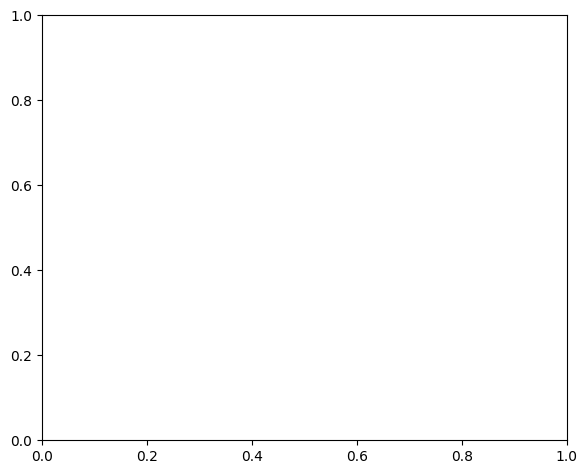

In [9]:
plot_gravity_measurements(receiver_list[0].locations, dpred)